# Companion Code for "One important lesson when building reforestation vs. deforestation monitoring systems"

In this notebook, we will study the spectral and optical signatures of a deforestation and reforestation plot in the Atlantic Forest.

## Step 1: Select Deforestation and Reforestation Point

In [54]:
# forest -> road
deforestation_point = (-47.137065, -23.821606)  # long, lat

# clearing -> forest
reforestation_point = (-47.259537, -23.505713) # long, lat

## Step 2: Download NDVI and EVI Time Series

Externally in Google Earth Engine.

## Step 3: Upload and Visualize Data

In [55]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from scipy.interpolate import make_interp_spline
import numpy as np

In [91]:
uploaded = files.upload()  # pick your CSV when prompted
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

Saving REFOREST_NDVI_EVI_2017-2025.csv to REFOREST_NDVI_EVI_2017-2025 (1).csv


In [93]:
df['date'] = pd.to_datetime(df['date'])
df['ndvi'] = pd.to_numeric(df['ndvi'], errors='coerce')
df['evi']  = pd.to_numeric(df['evi'],  errors='coerce')

# Drop masked/cloudy sentinel values and nulls
df = df[(df['ndvi'] > -1) & (df['evi'] > -1)].dropna(subset=['ndvi', 'evi'])
df = df.sort_values('date').reset_index(drop=True)
df = df.loc[(df['date'] > "2018-01-01") & (df['date'] < "2026-01-01")]

print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Total valid observations: {len(df)}")

# ── Monthly median smoothing ──────────────────────────────────────────────────
df['year_month'] = df['date'].dt.to_period('M')
monthly = (
    df.groupby('year_month')[['ndvi', 'evi']]
    .median()
    .reset_index()
)
monthly['date'] = monthly['year_month'].dt.to_timestamp()
monthly = monthly.sort_values('date').reset_index(drop=True)

Date range: 2018-02-24 → 2025-12-28
Total valid observations: 1459


In [94]:
import matplotlib.font_manager as fm

# Download the font
import urllib.request
urllib.request.urlretrieve(
    "https://github.com/tokotype/PlusJakartaSans/raw/master/fonts/ttf/PlusJakartaSans-Regular.ttf",
    "/tmp/PlusJakartaSans-Regular.ttf"
)

fm.fontManager.addfont("/tmp/PlusJakartaSans-Regular.ttf")
plt.rcParams['font.family'] = 'Plus Jakarta Sans'

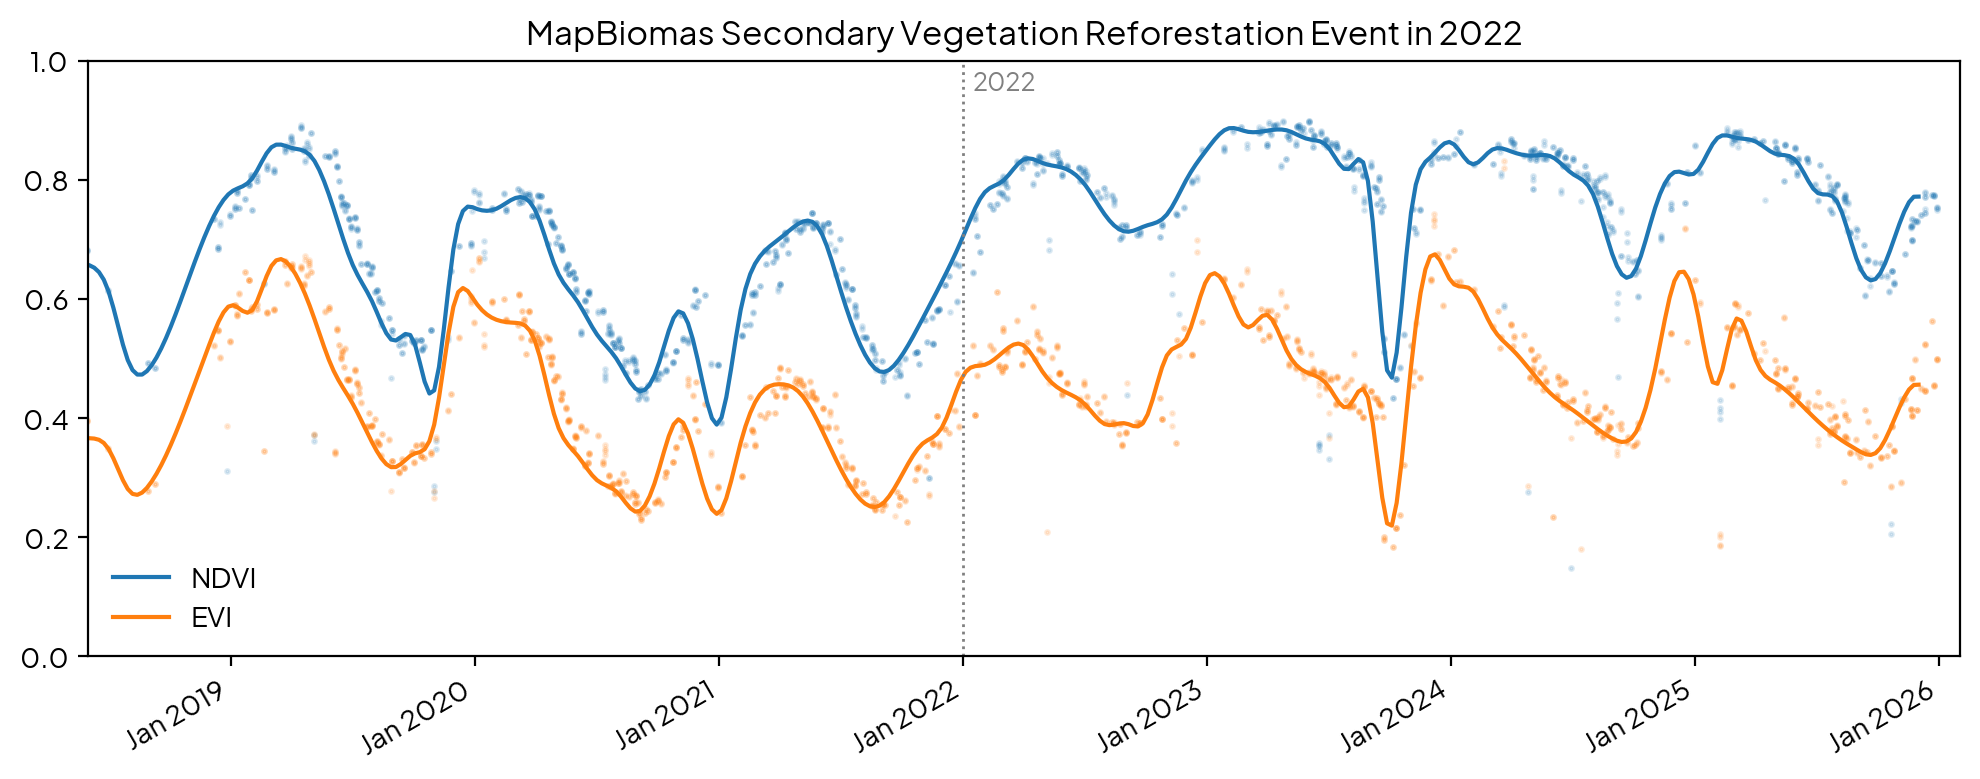

In [100]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy.interpolate import make_interp_spline

def smooth_spline(dates, values, n=400):
    x = mdates.date2num(list(dates))
    spl = make_interp_spline(x, values, k=3)
    x_s = np.linspace(x.min(), x.max(), n)
    return mdates.num2date(x_s), spl(x_s)

xs_ndvi, ys_ndvi = smooth_spline(monthly['date'], monthly['ndvi'])
xs_evi,  ys_evi  = smooth_spline(monthly['date'], monthly['evi'])

fig, ax = plt.subplots(figsize=(10, 4), dpi=200)

# Raw scatter
ax.scatter(df['date'], df['ndvi'], s=2, alpha=0.15, label='_nolegend_')
ax.scatter(df['date'], df['evi'],  s=2, alpha=0.15, label='_nolegend_')

# Spline lines (match colors via prop cycler reset)
ax.set_prop_cycle(None)
ax.plot(xs_ndvi, ys_ndvi, label='NDVI', linewidth=1.5)
ax.plot(xs_evi,  ys_evi,  label='EVI',  linewidth=1.5)

ax.axvline(pd.Timestamp('2022-01-01'), color='gray', linewidth=1, linestyle=':')
ax.text(pd.Timestamp('2022-01-15'), 0.95, '2022', color='gray', fontsize=9)
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2026-02-01'))

ax.set_ylim(0, 1)
ax.set_title("MapBiomas Secondary Vegetation Reforestation Event in 2022")
#ax.set_title("MapBiomas Primary Vegetation Deforestation Event in 2022")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
fig.autofmt_xdate()

ax.legend(frameon=False)
fig.tight_layout()
plt.show()